## STEP 1: <I><B>IMPORT OF LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("..\Data\global_cancer_patients_2015_2024.csv")

## STEP 2: <I><B>BASIC INFORMATION

In [3]:
data.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   Country_Region         50000 non-null  str    
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  str    
 11  Cancer_Stage           50000 non-null  str    
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes: float64(8)

In [5]:
data.duplicated().sum()

np.int64(0)

## STEP 3: <I><B>DESCRIPTIVE ANALYSIS

<b><div class="alert alert-info">Analysis of Age</div>

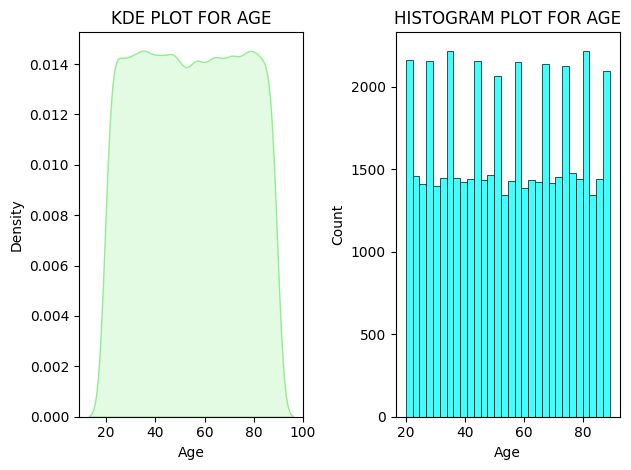

In [6]:
# plotting for age column

plt.Figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Age"], fill=True, color= "lightgreen")
plt.title("KDE PLOT FOR AGE")

plt.subplot(1,2,2)
sns.histplot(data["Age"], bins=30, color= "cyan")
plt.title("HISTOGRAM PLOT FOR AGE")

plt.tight_layout()
plt.show()

In [7]:
data["Age"].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

- INFERENCE <br>

   - Range: 20 to 89 years <br>
   - Mean Age: 54.42 years <br>
   - Standard Deviation: 20.22 <br>
   - IQR: Q1 (37) to Q3 (72) <br>
   - This suggests a broad representation of both young and elderly patients in the dataset, which supports age based comparative analysis.


<b><div class="alert alert-info">Analysis of Gender</div>

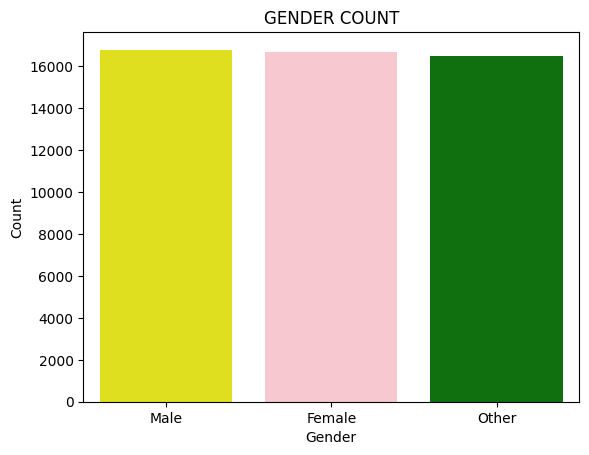

In [8]:
# plotting for gender column

sns.barplot(x= data["Gender"].value_counts().index,
            y= data["Gender"].value_counts().values,
            palette= ["yellow","pink","green"])

plt.title("GENDER COUNT")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [9]:
data["Gender"].value_counts()

Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

- INFERENCE <BR>
    
    - The dataset contains 3 gender categories(male, female, others) with sufficient amount. <br>
    - Gender distribution is sufficient for evaluating gender specific survival trends and diversity outcomes

- <b> Analysis of Countries

<b><div class="alert alert-info">Analysis of Countries</div>

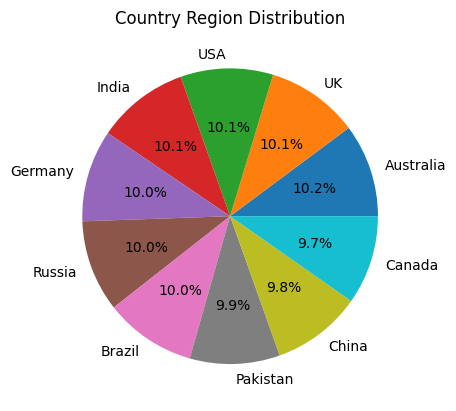

In [10]:
# plotting for countries column

plt.Figure(figsize=(5,5))
plt.pie(x= data["Country_Region"].value_counts().values,
        labels= data["Country_Region"].value_counts().index,
        autopct='%1.1f%%')

plt.title("Country Region Distribution")
plt.show()

In [11]:
data["Country_Region"].value_counts()

Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64

- INFERENCE<br>

    - Patients come from 10 different countries/regions with Australia being the most represented (5092 persons). <br>
    - Number of data points for each country is almost the same.<br>
    - This diversity enables the cross country comparison of cancer outcomes and treatment economic.

<b><div class="alert alert-info">Analysis of Cancer Types</div>

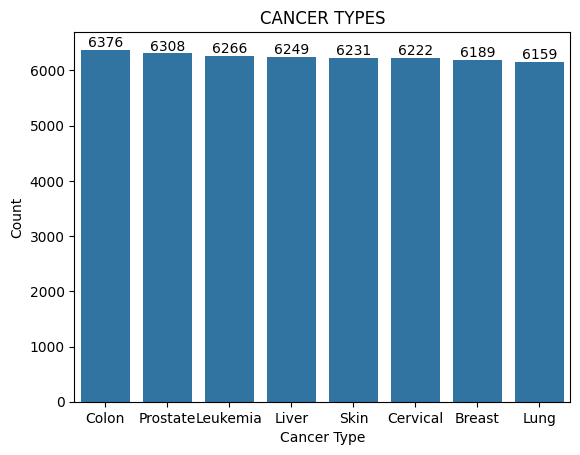

In [12]:
# plotting for Cancer_Type

sns.barplot(x= data["Cancer_Type"].value_counts().index,
            y= data["Cancer_Type"].value_counts().values)

for i, v in enumerate(data["Cancer_Type"].value_counts()):
    plt.text(i,v, str(v), ha="center", va="bottom")

plt.title("CANCER TYPES")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

In [13]:
data["Cancer_Type"].value_counts()

Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64

- INFERENCE <BR>

    - We have in total 8 types of cancer with each cancer having approx same number of data points under the labels.<br>
    - Most common cancer is colon followed by Prostate.

<b><div class="alert alert-info">Analysis of Cancer Stages</div>

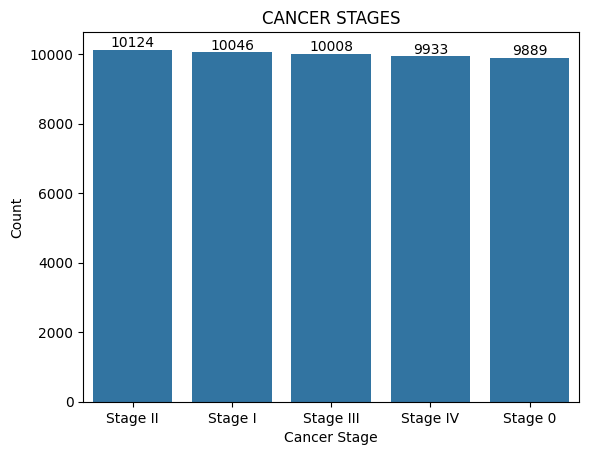

In [14]:
# plotting of Cancer Stage

sns.barplot(x= data["Cancer_Stage"].value_counts().index,
            y= data["Cancer_Stage"].value_counts().values)

for i, v in enumerate(data["Cancer_Stage"].value_counts()):
    plt.text(i,v, str(v), ha="center", va="bottom")

plt.title("CANCER STAGES")
plt.xlabel("Cancer Stage")
plt.ylabel("Count")
plt.show()

In [15]:
data["Cancer_Stage"].value_counts()

Cancer_Stage
Stage II     10124
Stage I      10046
Stage III    10008
Stage IV      9933
Stage 0       9889
Name: count, dtype: int64

- INFERENCE<br>

    - Cancer Stage have 5 stages with values ranging from 0 to 4.<BR>
    - Stage 2 is the most common one with eaach stage have the same number of data points under it's label

<b><div class="alert alert-info">Analysis of Treatment Cost</div>

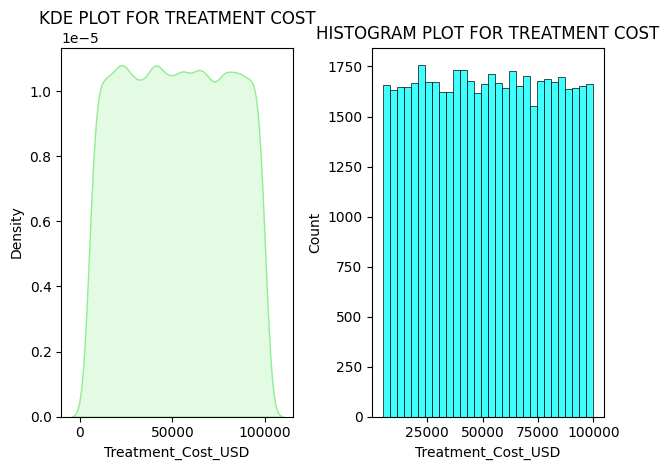

In [16]:
# plotting for treatment cost


# plotting for age column

plt.Figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Treatment_Cost_USD"], fill=True, color= "lightgreen")
plt.title("KDE PLOT FOR TREATMENT COST")

plt.subplot(1,2,2)
sns.histplot(data["Treatment_Cost_USD"], bins=30, color= "cyan")
plt.title("HISTOGRAM PLOT FOR TREATMENT COST")

plt.tight_layout()
plt.show()

In [17]:
data["Treatment_Cost_USD"].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: Treatment_Cost_USD, dtype: float64

- INFERENCE<BR>

    - Treatment cost USD have no skewness.<br>
    - There are almost same number of data point under each bin as observed by Histogram.

<b><div class="alert alert-info">Analysis of Risk Factors</div>

In [18]:
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='str')

In [19]:
risk_factors = ['Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

summary = data[risk_factors].agg(["mean", "std", "min", "max"])
summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


- INFERENCE <BR>

    - These variables have nearly identical means and standard deviations indicating they are likely designed in the same standardized scale.<br>
    - They are essential in studying interaction effects(eg.., genetic risk, smoking) on survival.

## STEP 4: <I><B>INFERENTIAL & PREDICTIVE ANALYSIS

<b><div class="alert alert-success">Determine the relationship between risk factors and cancer severity.</div>

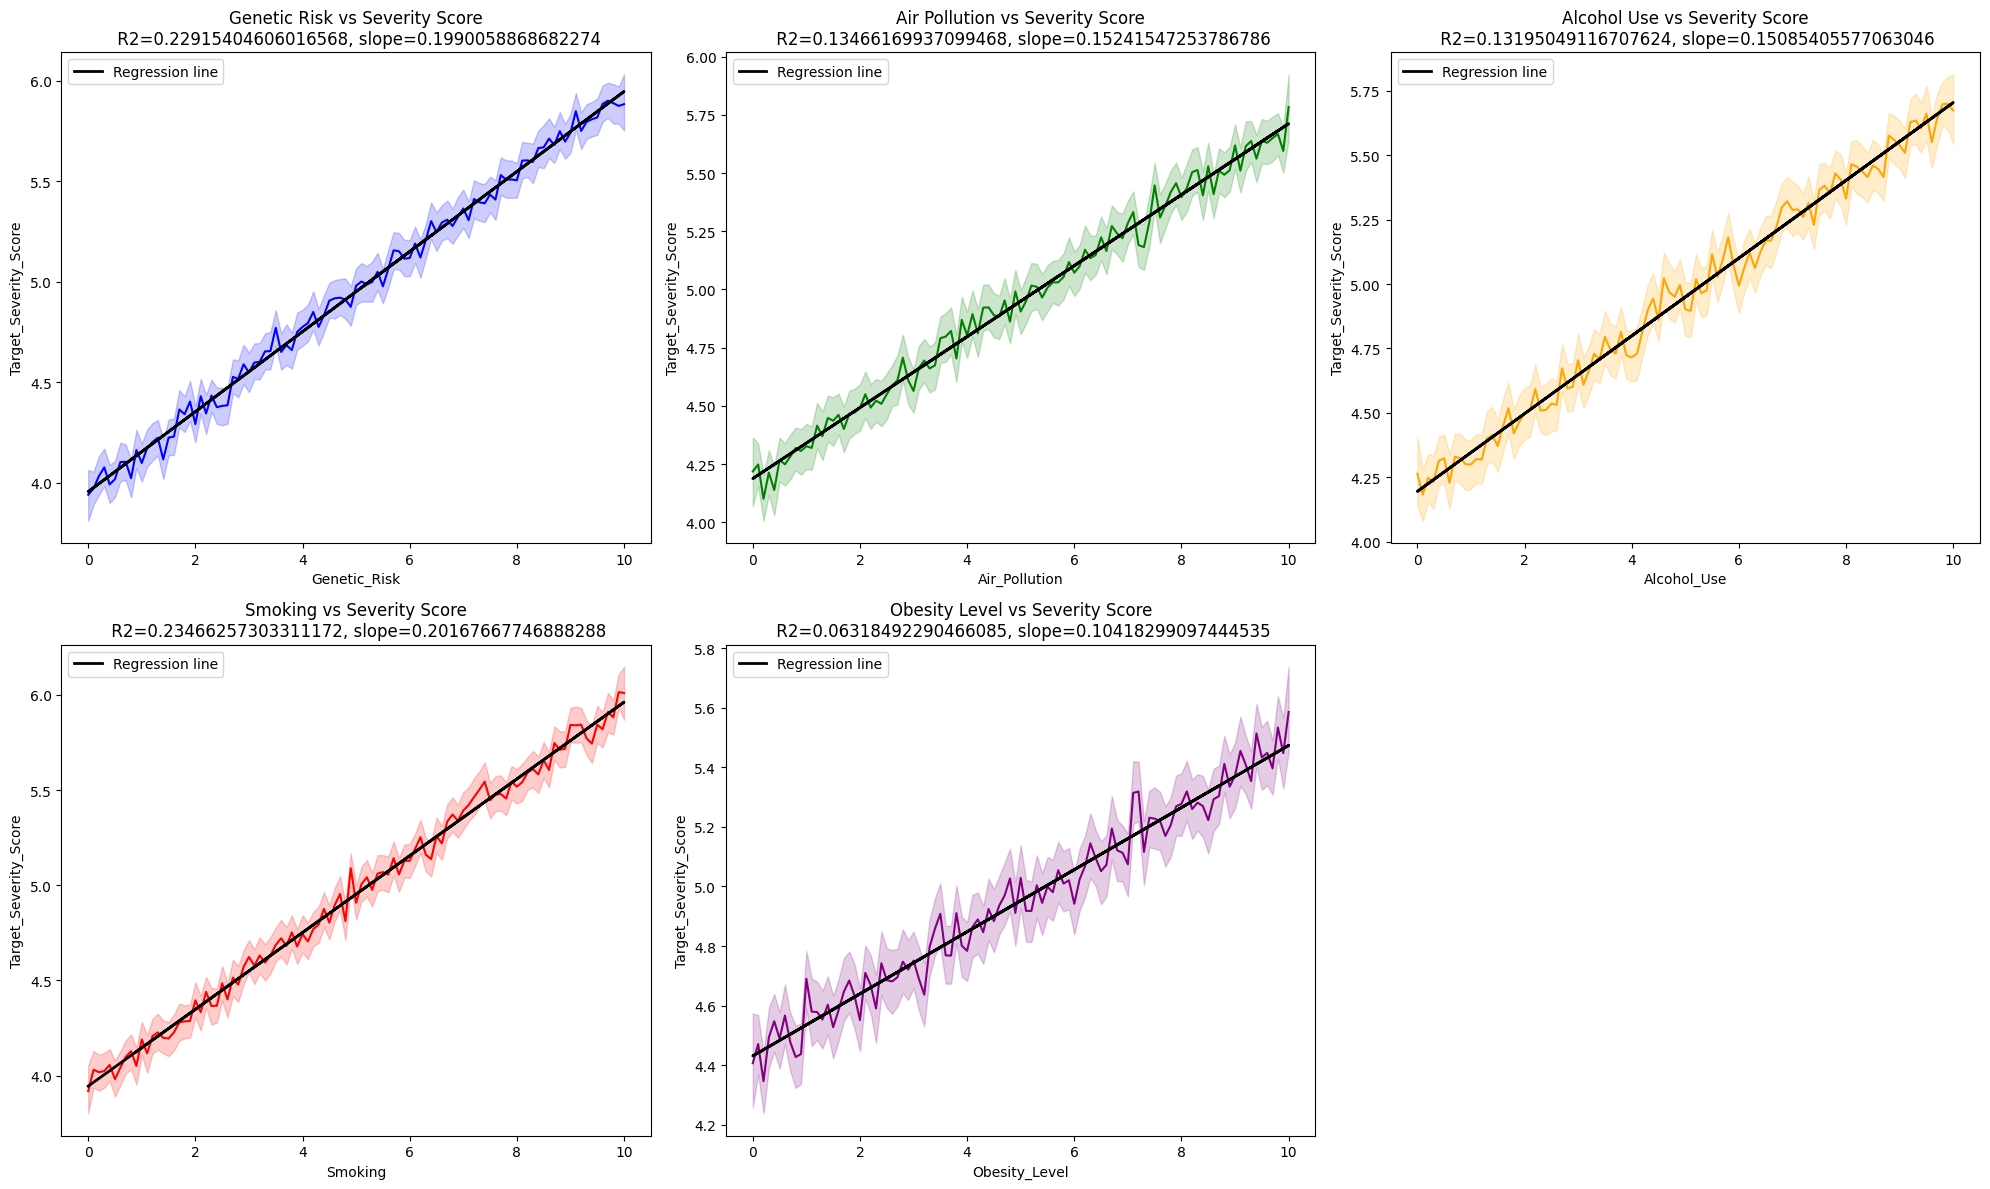

In [20]:
from scipy.stats import linregress

risk_factors = ['Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles = ['Genetic Risk', 'Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors = [ "blue", "green", "orange", "red", "purple"]

plt.figure(figsize=(20,12))

for i, (factor, title, color) in enumerate(zip(risk_factors, titles, colors),1):
    plt.subplot(2,3,i)

    x = data[factor]
    y = data["Target_Severity_Score"]
    slope , intercept , r_value , p_value , std_err  = linregress(x,y)
    r_squared = r_value**2

    sns.lineplot(x=factor, y="Target_Severity_Score", data=data, color=color)
    plt.plot(x, x*slope+intercept, color="black", linewidth=2, label="Regression line")
    plt.title(f"{title} vs Severity Score\n R2={r_squared}, slope={slope}")
    plt.xlabel(factor)
    plt.ylabel("Target_Severity_Score")
    plt.legend()

plt.tight_layout()
plt.show()

<b><div class="alert alert-success">Analyze the proportion of early stage diagnoses by cancer type.</div>

In [21]:
data["Cancer_Type"].unique()

<StringArray>
['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical', 'Prostate',
 'Liver']
Length: 8, dtype: str

- <B>FOR LUNG

In [22]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Lung"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early lungs cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage II     1298
Stage IV     1286
Stage III    1208
Stage 0      1185
Stage I      1182
Name: count, dtype: int64
Total cancer are:6159
Early stage detected are:2367
Percentage of early lungs cancer detected are: 38.43156356551388


- <B>FOR LEUKEMIA

In [23]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Leukemia"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early Leukemia cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage IV     1311
Stage 0      1255
Stage III    1251
Stage II     1227
Stage I      1222
Name: count, dtype: int64
Total cancer are:6266
Early stage detected are:2477
Percentage of early Leukemia cancer detected are: 39.53080114905841


- <B>FOR BREAST

In [24]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Breast"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early Breast cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage II     1273
Stage III    1270
Stage 0      1231
Stage I      1212
Stage IV     1203
Name: count, dtype: int64
Total cancer are:6189
Early stage detected are:2443
Percentage of early Breast cancer detected are: 39.47325900791727


- <B>FOR COLON

In [25]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Colon"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early colon cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage I      1321
Stage III    1303
Stage 0      1256
Stage IV     1252
Stage II     1244
Name: count, dtype: int64
Total cancer are:6376
Early stage detected are:2577
Percentage of early colon cancer detected are: 40.41718946047679


- <B>FOR SKIN

In [26]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Skin"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early skin cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage II     1294
Stage I      1275
Stage 0      1243
Stage III    1230
Stage IV     1189
Name: count, dtype: int64
Total cancer are:6231
Early stage detected are:2518
Percentage of early skin cancer detected are: 40.41084898090194


- <B>FOR CERVICAL

In [27]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Cervical"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early Cervical cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage I      1290
Stage II     1286
Stage III    1238
Stage IV     1218
Stage 0      1190
Name: count, dtype: int64
Total cancer are:6222
Early stage detected are:2480
Percentage of early Cervical cancer detected are: 39.85856637737062


- <B>FOR PROSTATE

In [28]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Prostate"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early prostate cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage I      1276
Stage IV     1273
Stage III    1271
Stage 0      1259
Stage II     1229
Name: count, dtype: int64
Total cancer are:6308
Early stage detected are:2535
Percentage of early prostate cancer detected are: 40.187064045656314


- <B>FOR LIVER

In [29]:
# Count at each stage
stage_counts = data[data["Cancer_Type"] =="Liver"]["Cancer_Stage"].value_counts()
print(f"Cancer at each stages are:{stage_counts}")

# total cancer of this type
total_cancer = stage_counts.sum()
print(f"Total cancer are:{total_cancer}")

# early stage detected count
early_stage = stage_counts.get("Stage 0", 0) + stage_counts.get("Stage I", 0)
print(f"Early stage detected are:{early_stage}")

# percentage of earlt stage detected
percentage_early_stage = (early_stage/total_cancer)*100
print(f"Percentage of early liver cancer detected are: {percentage_early_stage}")

Cancer at each stages are:Cancer_Stage
Stage II     1273
Stage 0      1270
Stage I      1268
Stage III    1237
Stage IV     1201
Name: count, dtype: int64
Total cancer are:6249
Early stage detected are:2538
Percentage of early liver cancer detected are: 40.614498319731155


<b><div class="alert alert-success">Identify key predictors of cancer severity and survival years.</div>

In [30]:
features = ['Age', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

target = ['Survival_Years', 'Target_Severity_Score']

In [31]:
# calculating correlation

pearson_corr = data[features+target].corr(method="pearson")
spearman_corr = data[features+target].corr(method="spearman")

In [32]:
pearson_corr

,Age,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Survival_Years,Target_Severity_Score
Age,1.000000,0.002229,0.001101,-0.004130,0.001734,-0.002706,-0.000147,-0.001481
Genetic_Risk,0.002229,1.000000,-0.004492,-0.002558,-0.003718,0.003522,0.001708,0.478700
Air_Pollution,0.001101,-0.004492,1.000000,0.003511,0.003549,0.006507,0.000893,0.366963
Alcohol_Use,-0.004130,-0.002558,0.003511,1.000000,-0.002938,0.007425,-0.000527,0.363250
Smoking,0.001734,-0.003718,0.003549,-0.002938,1.000000,0.005828,0.001371,0.484420
Obesity_Level,-0.002706,0.003522,0.006507,0.007425,0.005828,1.000000,0.009771,0.251366
Survival_Years,-0.000147,0.001708,0.000893,-0.000527,0.001371,0.009771,1.000000,0.004161
Target_Severity_Score,-0.001481,0.478700,0.366963,0.363250,0.484420,0.251366,0.004161,1.000000


In [33]:
pearson_results = pearson_corr[target]        #slicing out the relationship only with the target columns
pearson_results

,Survival_Years,Target_Severity_Score
Age,-0.000147,-0.001481
Genetic_Risk,0.001708,0.478700
Air_Pollution,0.000893,0.366963
Alcohol_Use,-0.000527,0.363250
Smoking,0.001371,0.484420
Obesity_Level,0.009771,0.251366
Survival_Years,1.000000,0.004161
Target_Severity_Score,0.004161,1.000000


In [34]:
spearman_corr

,Age,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Survival_Years,Target_Severity_Score
Age,1.000000,0.002207,0.001102,-0.004133,0.001692,-0.002732,-0.000149,-0.002076
Genetic_Risk,0.002207,1.000000,-0.004472,-0.002571,-0.003707,0.003494,0.001684,0.472193
Air_Pollution,0.001102,-0.004472,1.000000,0.003507,0.003561,0.006496,0.000841,0.357528
Alcohol_Use,-0.004133,-0.002571,0.003507,1.000000,-0.002904,0.007401,-0.000543,0.354694
Smoking,0.001692,-0.003707,0.003561,-0.002904,1.000000,0.005838,0.001372,0.477881
Obesity_Level,-0.002732,0.003494,0.006496,0.007401,0.005838,1.000000,0.009780,0.243152
Survival_Years,-0.000149,0.001684,0.000841,-0.000543,0.001372,0.009780,1.000000,0.003431
Target_Severity_Score,-0.002076,0.472193,0.357528,0.354694,0.477881,0.243152,0.003431,1.000000


In [35]:
spearman_results = spearman_corr[target]       #slicing out the relationship only with the target columns
spearman_results

,Survival_Years,Target_Severity_Score
Age,-0.000149,-0.002076
Genetic_Risk,0.001684,0.472193
Air_Pollution,0.000841,0.357528
Alcohol_Use,-0.000543,0.354694
Smoking,0.001372,0.477881
Obesity_Level,0.009780,0.243152
Survival_Years,1.000000,0.003431
Target_Severity_Score,0.003431,1.000000


In [36]:
# Combine both

correlation_df = pd.concat([pearson_results, spearman_results], axis=1, keys=["Pearson","Spearman"])
correlation_df

Pearson                             Spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

- Correlation with Target Severity Score


<table>
  <tr>
    <th>Feature</th>
    <th>Pearson</th>
    <th>Spearman</th>
    <th>Interpretation</th>
  </tr>
  <tr>
    <td><b>Smoking</td>
    <td>0.484</td>
    <td>0.478</td>
    <td>Strong positive correlation. Higher smoking levels are associated with higher severity scores.</td>
  </tr>
  <tr>
    <td><b>Genetic_Risk</td>
    <td>0.479</td>
    <td>0.472</td>
    <td>Strong positive correlation. Genetic predisposition is a significant factor in severity.</td>
  </tr>
  <tr>
    <td><b>Air_Pollution</td>
    <td>0.367</td>
    <td>0.358</td>
    <td>Moderate positive correlation. Suggests environmental exposure contributes to severity.</td>
  </tr>
  <tr>
    <td><b>Alcohol_Use</td>
    <td>0.363</td>
    <td>0.355</td>
    <td>Moderate positive correlation. Alcohol consumption may play a role in worsening severity.</td>
  </tr>
  <tr>
    <td><b>Obesity_Level</td>
    <td>0.251</td>
    <td>0.243</td>
    <td>Weak to moderate positive correlation. There is some association between obesity and severity.</td>
  </tr>
  <tr>
    <td><b>Treatment_Cost</td>
    <td>-0.466</td>
    <td>-0.459</td>
    <td>Strong negative correlation. Higher severity cases tend to have lower treatment costs, which may reflect healthcare access issues or late-stage diagnosis limiting treatment.</td>
  </tr>
</table>




- Correlation with Survival Years



<table>
  <tr>
    <th>Feature</th>
    <th>Pearson</th>
    <th>Spearman</th>
    <th>Interpretation</th>
  </tr>
  <tr>
    <td><b>All Features</td>
    <td>~0.000</td>
    <td>~0.000</td>
    <td>Negligible or no correlation. These variables do not show any significant linear or monotonic association with survival year/duration.</td>
  </tr>
</table>

- <b> Random Forest for Feature importance

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [38]:
# conversion of categorical columns into numerical

categorical_cols = ["Gender","Country_Region","Cancer_Type","Cancer_Stage"]

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

- <b>Feature importance for Target Severity Score

In [39]:
# Preparing features and targets

x = data.drop(columns=["Patient_ID","Treatment_Cost_USD","Survival_Years","Target_Severity_Score"])

y_severity = data["Target_Severity_Score"]

In [40]:
# Train Test Split

x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(x, y_severity, test_size=0.2, random_state=42)

In [41]:
# Train the Model

model = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)
model.fit(x_train_s, y_train_s)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [42]:
# Evaluate the Model

train_r2_severity = r2_score(y_train_s, model.predict(x_train_s))
test_r2_severity = r2_score(y_test_s, model.predict(x_test_s) )

In [43]:
print(train_r2_severity)
print(test_r2_severity)

0.9692278716073492
0.7686160945581657


In [44]:
feature_importance_severity = pd.Series(model.feature_importances_ , index= x.columns,).sort_values(ascending=True)

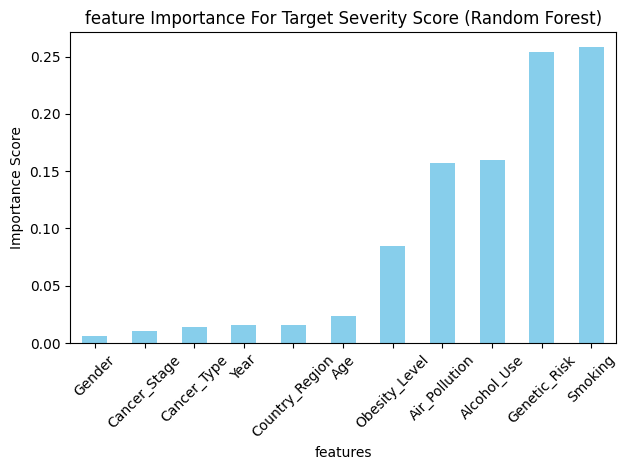

In [45]:
# plotting of important features

plt.Figure(figsize=(18,6))
feature_importance_severity.plot(kind="bar", color="skyblue")
plt.title("feature Importance For Target Severity Score (Random Forest)")
plt.xlabel("features")
plt.ylabel("Importance Score")
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

- <b>Feature importance for Survival Years

In [46]:
y_survival = data["Survival_Years"]

In [47]:
# Train Test Split

x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(x, y_survival, test_size=0.2, random_state=42)

In [48]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [5,10,None],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2] 
}

In [49]:
# Train the Model

# model = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42)
# model.fit(x_train_s, y_train_s)

model = RandomForestRegressor(random_state=40)
grid_cv = GridSearchCV(model, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_cv.fit(x_train_s, y_train_s)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=40)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [50]:
best_rf_estimators = grid_cv.best_estimator_

In [51]:
# Evaluate the Model

train_r2_severity = r2_score(y_train_s, best_rf_estimators.predict(x_train_s))
test_r2_severity = r2_score(y_test_s, best_rf_estimators.predict(x_test_s) )

In [52]:
print(train_r2_severity)
print(test_r2_severity)

0.008880766282441055
0.00017030831704056837


<Axes: xlabel='Survival_Years', ylabel='Count'>

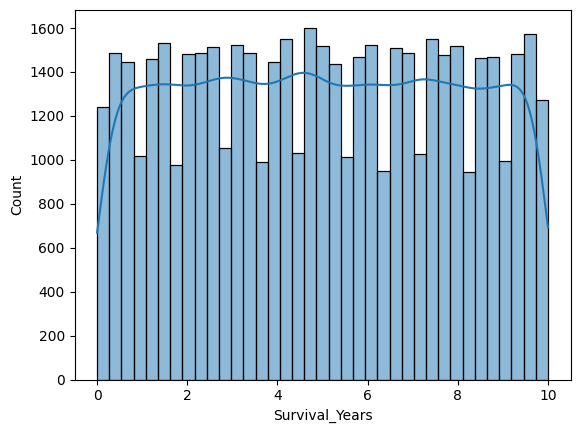

In [53]:
import seaborn as sns

sns.histplot(data["Survival_Years"], kde=True)

In [54]:
data.corr(numeric_only=True)["Survival_Years"].sort_values(ascending=True)

Gender                  -0.007121
Cancer_Stage            -0.003014
Cancer_Type             -0.001717
Alcohol_Use             -0.000527
Treatment_Cost_USD      -0.000429
Age                     -0.000147
Year                     0.000018
Air_Pollution            0.000893
Smoking                  0.001371
Genetic_Risk             0.001708
Target_Severity_Score    0.004161
Country_Region           0.005121
Obesity_Level            0.009771
Survival_Years           1.000000
Name: Survival_Years, dtype: float64

- INFERENCE

    -  The information in the column does not help the model figure out how long someone will survive.

<b><div class="alert alert-success">Explore the economic burden of cancer treatment across different demographics and countries.</div>

In [55]:
data = pd.read_csv("..\Data\global_cancer_patients_2015_2024.csv")

In [56]:
data.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [57]:
country_gender_cost = data.groupby(["Country_Region","Gender"])["Treatment_Cost_USD"].mean().reset_index()

In [58]:
data["Age_Group"] = pd.cut(data["Age"], bins=[0,30,45,60,75,100], labels=["0 30","31 45", "46 60", "61 75", "75+"])

In [59]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61 75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31 45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,75+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31 45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31 45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,75+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31 45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61 75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0 30


In [60]:
country_age_gender_cost = data.groupby(["Country_Region","Age_Group","Gender"])["Treatment_Cost_USD"].mean().reset_index()

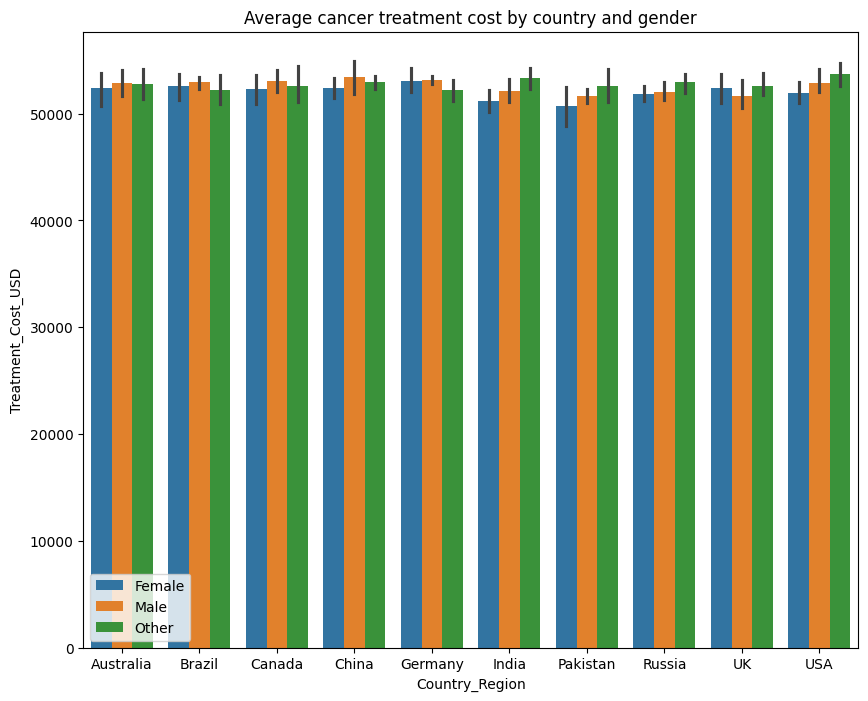

In [61]:
# plotting for cost and demographic

plt.figure(figsize=(10,8))
sns.barplot(data=country_age_gender_cost, x="Country_Region", y="Treatment_Cost_USD", hue="Gender")
plt.legend()
plt.title("Average cancer treatment cost by country and gender")
plt.show()

In [62]:
country_age_cost = data.groupby(["Country_Region","Age_Group"])["Treatment_Cost_USD"].mean().reset_index()

In [63]:
heatmap_data = country_age_cost.pivot(index="Age_Group", columns="Country_Region", values="Treatment_Cost_USD")

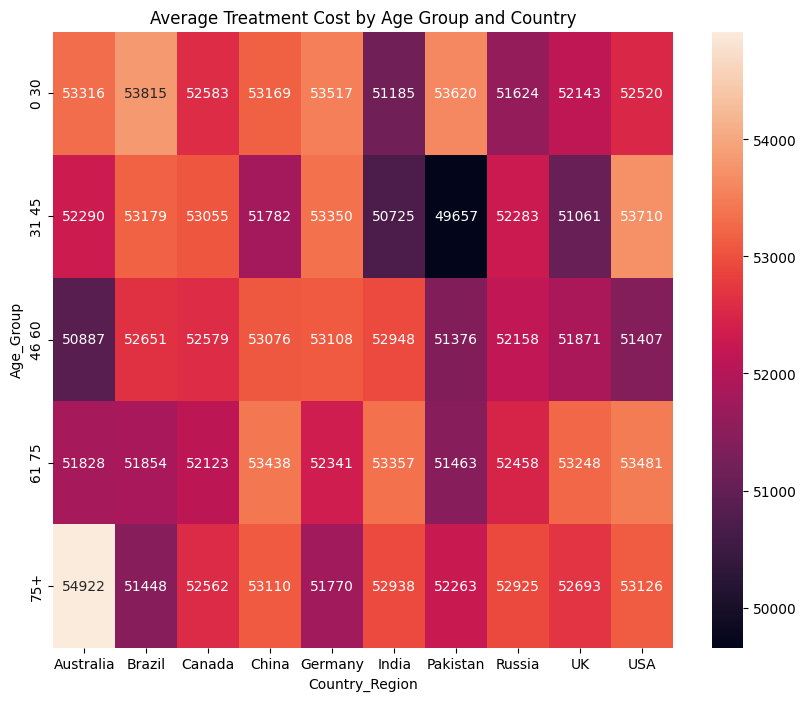

In [64]:
# plotting of heatmap

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, annot=True, fmt= ".0f")
plt.title("Average Treatment Cost by Age Group and Country")
plt.show()

<b><div class="alert alert-success">Assess whether higher treatment cost is associated with longer survival.</div>

- Null Hypothesis (Ho) : There is no correlation between treatment cost and survival years. <br>
- Alternative Hypothesis (H1) :   There is a correlation (positive or negative) between treatment cost and survival years.

In [65]:
from scipy.stats import pearsonr , spearmanr

In [66]:
x = data["Treatment_Cost_USD"]
y = data["Survival_Years"]

In [67]:
# performing pearson correlation test

pearson_corr, pearson_p = pearsonr(x,y)
print(F"Pearson Correlation Coefficient is : {pearson_corr}")
print(F"Pearson P-Value is : {pearson_p}")

Pearson Correlation Coefficient is : -0.0004294054283021519
Pearson P-Value is : 0.9235082012963309


In [68]:
# performing spearman correlation test

spearman_corr, spearman_p = spearmanr(x,y)
print(F"Spearman Correlation Coefficient is : {spearman_corr}")
print(F"Spearman P-Value is : {spearman_p}")

Spearman Correlation Coefficient is : -0.0004454737292549569
Spearman P-Value is : 0.9206551702014917


In [69]:
alpha = 0.05

def interpret_correlation(corr, p, method):
    if p < alpha:
        print(f"{method}, we reject null hypothesis")
    else:
        print(f"{method}, we failed to reject  null hypothesis")

In [70]:
interpret_correlation(pearson_corr, pearson_p, "Pearson")

Pearson, we failed to reject  null hypothesis


In [71]:
interpret_correlation(spearman_corr, spearman_p, "Spearman")

Spearman, we failed to reject  null hypothesis


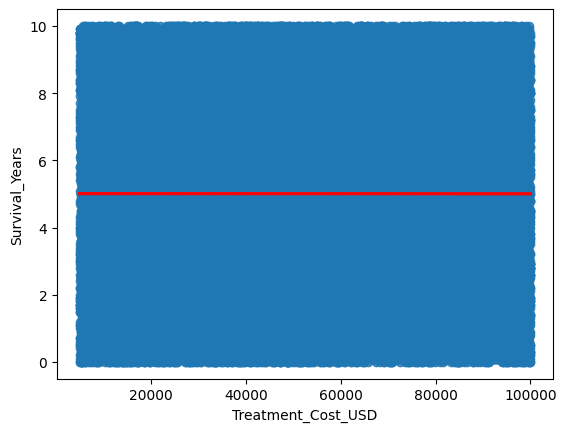

In [72]:
# plotting 

sns.regplot(x=x, y=y, line_kws={"color":"red"})
plt.show()

- There is no relationship between treatment cost and survival years.

<b><div class="alert alert-success">Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years.</div>

In [73]:
data = pd.read_csv("..\Data\global_cancer_patients_2015_2024.csv")

In [74]:
data.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [75]:
cancer_stage_order = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']

In [76]:
group_states = data.groupby("Cancer_Stage")[["Treatment_Cost_USD","Survival_Years"]].mean().reset_index()

In [77]:
group_states

,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


- Treatment Cost vs. Cancer Stage<br>
    - Null Hypothesis (Ho) : The average treatment cost is the same across all cancer stages.<br>
    - Alternative Hypothesis (H1) : Atleast one stage has a different average cost.<br>

- Survival Years vs. Cancer Stage<br>
    - Null Hypothesis (Ho) : The average survival years are the same across all cancer stages.<br>
    - Alternative Hypothesis (H1) : Atleast one stage has a different survival years.<br>

In [78]:
grouped_costs = []
grouped_survival = []



for stage in cancer_stage_order:
    stage_data = data[data["Cancer_Stage"]==stage]
    cost = stage_data["Treatment_Cost_USD"]
    survival = stage_data["Survival_Years"]
    grouped_costs.append(cost)
    grouped_survival.append(survival)

In [79]:
grouped_costs

[1        12573.41
 6         9790.83
 17       56875.63
 22       89075.81
 29       32889.23
            ...   
 49988    52763.24
 49989    30400.57
 49995    71463.70
 49997     5338.25
 49999    64023.82
 Name: Treatment_Cost_USD, Length: 9889, dtype: float64,
 3        67446.25
 7        17161.40
 10       15093.39
 11       72315.19
 19       40131.04
            ...   
 49979     9090.63
 49981    94507.13
 49987    51598.72
 49993    75193.19
 49996    49619.66
 Name: Treatment_Cost_USD, Length: 10046, dtype: float64,
 2         6984.33
 8        56458.48
 9        56133.45
 12       99120.52
 13       94210.93
            ...   
 49973    58707.61
 49978    88123.42
 49990    38290.91
 49991    73592.91
 49992    99623.46
 Name: Treatment_Cost_USD, Length: 10124, dtype: float64,
 0        62913.44
 4        77977.12
 16       59285.13
 28       97036.73
 31       65719.90
            ...   
 49968    46434.35
 49976    52551.96
 49980    72094.76
 49983    47086.44
 49994    

In [80]:
grouped_survival

[1        4.7
 6        1.0
 17       1.9
 22       9.9
 29       0.2
         ... 
 49988    4.7
 49989    2.2
 49995    1.0
 49997    2.7
 49999    7.4
 Name: Survival_Years, Length: 9889, dtype: float64,
 3        1.6
 7        6.2
 10       1.0
 11       6.0
 19       5.4
         ... 
 49979    5.7
 49981    7.6
 49987    7.5
 49993    4.2
 49996    0.4
 Name: Survival_Years, Length: 10046, dtype: float64,
 2        7.1
 8        6.5
 9        5.7
 12       8.0
 13       7.1
         ... 
 49973    1.3
 49978    0.9
 49990    1.1
 49991    9.5
 49992    9.3
 Name: Survival_Years, Length: 10124, dtype: float64,
 0        5.9
 4        2.9
 16       0.5
 28       9.7
 31       9.8
         ... 
 49968    4.9
 49976    4.2
 49980    6.0
 49983    0.7
 49994    3.0
 Name: Survival_Years, Length: 10008, dtype: float64,
 5        9.5
 14       8.3
 30       5.1
 33       5.5
 34       3.8
         ... 
 49972    9.9
 49982    7.5
 49984    9.1
 49985    7.4
 49998    7.5
 Name: Survival

In [81]:
# Check for Normality

from scipy.stats import shapiro, f_oneway

normal_cost = 0
normal_survival = 0

for i in range(len(cancer_stage_order)):
    cost_p = shapiro(grouped_costs[i]).pvalue
    survival_p = shapiro(grouped_survival[i]).pvalue
    print(f"Cost {cost_p} for group {i}")
    print(f"Survival {survival_p} for group {i}")

    if cost_p < 0.05:
        normal_cost+=1
    if survival_p < 0.05:
        normal_survival+=1


Cost 1.5471821061637387e-47 for group 0
Survival 1.6291039522109283e-47 for group 0
Cost 7.306523956950957e-48 for group 1
Survival 7.575551046259697e-48 for group 1
Cost 8.943579643043388e-48 for group 2
Survival 4.041659465829829e-48 for group 2
Cost 5.267270033022367e-48 for group 3
Survival 1.3648520457944784e-47 for group 3
Cost 1.5838640189581322e-47 for group 4
Survival 2.2992598289836786e-47 for group 4


In [82]:
print(normal_cost)
print(normal_survival)

5
5


In [83]:
from scipy.stats import kruskal

In [84]:
kruskal_cost = kruskal(*grouped_costs)
kruskal_survival = kruskal(*grouped_survival)

p_cost = kruskal_cost.pvalue
p_survival = kruskal_survival.pvalue

In [85]:
print(f"The p value for kruskal cost is: {p_cost}")
print(f"The p value for kruskal survival is: {p_survival}")


The p value for kruskal cost is: 0.4254451689062656
The p value for kruskal survival is: 0.6033078729984223


- INFERENCE<br>

    - Kruskal-Wallis Test : Treatment Cost across Cancer Stages<br>
        - P-Value: 0.4254<br>
        - Conclusion: No significant difference in treatment costs among cancer stages.<br>
    
    - Kruskal-Wallis Test : Survival Years across Cancer Stages<br>
        - P-Value: 0.6033<br>
        - Conclusion: No significant difference in survival years among cancer stages.<br>


<b><div class="alert alert-success">Examine whether higher genetic risk amplifies the negative effects of smoking on cancer severity and survival outcomes.</div>

- Null Hypothesis (Ho) : <br>
    - The interaction effect between genetic risk and smoking on cancer severity is not significant.<br>
    (Genetic risk does not emplify or alter the effect of smoking.)<br>

- Alternative Hypothesis (H1) : <br>
    - The interaction effect between genetic risk and smoking on cancer severity is significant.<br>
    (Genetic risk does emplify or alter the effect of smoking.)

In [86]:
import statsmodels.formula.api as smf

In [87]:
model = smf.ols("Target_Severity_Score ~ Genetic_Risk * Smoking", data= data).fit()

In [88]:
model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Results: Ordinary least squares
=========================================================================
Model:              OLS                   Adj. R-squared:     0.466      
Dependent Variable: Target_Severity_Score AIC:                128780.2176
Date:               2026-05-19 15:29      BIC:                128815.4967
No. Observations:   50000                 Log-Likelihood:     -64386.    
Df Model:           3                     F-statistic:        1.452e+04  
Df Residuals:       49996                 Prob (F-statistic): 0.00       
R-squared:          0.466                 Scale:              0.76924    
--------------------------------------------------------------------------
                       Coef.   Std.Err.     t      P>|t|    [0.025  0.975]
--------------------------------------------------------------------------
Intercept              2.9363    0.0157  187.0523  0.0000   2.9056  2.9671
Genetic_Risk           0.2009    0.0027   74.1303  0.0000   0.1956  0.2062
Smoking                0.2036    0.0027   74.7710  0.0000   0.1982  0.2089
Genetic_Risk:Smoking  -0.0002    0.0005   -0.4842  0.6283  -0.0012  0.0007
-------------------------------------------------------------------------
Omnibus:                353.462         Durbin-Watson:            1.998  
Prob(Omnibus):          0.000           Jarque-Bera (JB):         240.715
Skew:                   -0.004          Prob(JB):                 0.000  
Kurtosis:               2.660           Condition No.:            139    
=========================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is
correctly specified.
"""

In [89]:
model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,2.936343,0.015698,187.052326,0.000000,2.905575,2.967111
Genetic_Risk,0.200893,0.002710,74.130262,0.000000,0.195581,0.206204
Smoking,0.203562,0.002722,74.770965,0.000000,0.198226,0.208898
Genetic_Risk:Smoking,-0.000228,0.000471,-0.484187,0.628255,-0.001150,0.000694


In [90]:
model.summary2().tables[1].loc["Genetic_Risk:Smoking"]

Coef.      -0.000228
Std.Err.    0.000471
t          -0.484187
P>|t|       0.628255
[0.025     -0.001150
0.975]      0.000694
Name: Genetic_Risk:Smoking, dtype: float64

- INFERENCE <BR>

    - P-Value : o.628255<br>
    - Interaction Coefficient : -0.000228<br>
    - here p-value > 0.05 , so we fail to reject the null hypothesis.